# Chapter 8 — Learning Signal and Ignoring Noise

## Learning Objectives

This notebook covers overfitting, generalization, early stopping, dropout, training/test split, and batch gradient descent.

## Theoretical Explanation

A neural network can memorize training data while failing on new data. This is overfitting. Generalization is the ability to perform well on unseen examples. Regularization methods such as early stopping and dropout reduce memorization and encourage the model to learn signal rather than noise.

Dropout randomly turns off hidden units during training. This forces the network to distribute knowledge across multiple pathways. Batch gradient descent updates weights using groups of examples, which produces smoother updates than pure stochastic learning.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dropout Mask Demonstration

In [2]:
hidden = np.array([[0.2, 0.5, 1.0, 0.0, 0.7]])
mask = (np.random.rand(*hidden.shape) > 0.5).astype(float)
dropped = hidden * mask * 2
print('Original hidden layer:', hidden)
print('Dropout mask:', mask)
print('After dropout with scaling:', dropped)

Original hidden layer: [[0.2 0.5 1.  0.  0.7]]
Dropout mask: [[0. 1. 1. 1. 0.]]
After dropout with scaling: [[0. 1. 2. 0. 0.]]


### Output Interpretation

Some hidden units are set to zero. Scaling keeps the expected magnitude similar, which helps training remain stable.

## 2. Mini-Batch Training on Synthetic Data

Final loss: 0.00872


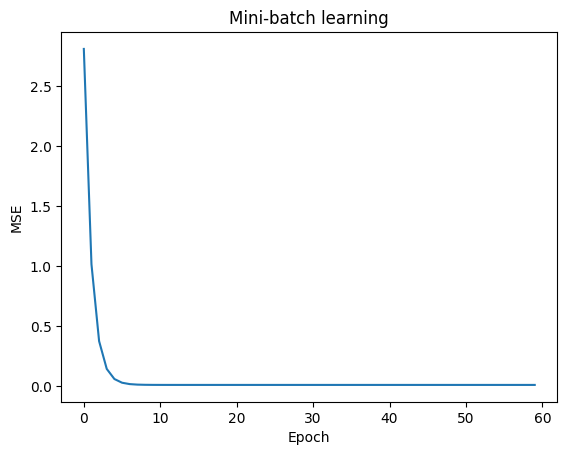

In [3]:
X = np.random.randn(200, 4)
true_w = np.array([[1.0], [-2.0], [0.5], [1.5]])
y = X.dot(true_w) + 0.1*np.random.randn(200,1)
w = np.random.randn(4,1) * 0.1
alpha = 0.05
batch_size = 20
losses = []
for epoch in range(60):
    for start in range(0, len(X), batch_size):
        xb = X[start:start+batch_size]
        yb = y[start:start+batch_size]
        pred = xb.dot(w)
        delta = pred - yb
        w -= alpha * xb.T.dot(delta) / len(xb)
    losses.append(np.mean((X.dot(w)-y)**2))
print('Final loss:', round(losses[-1], 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Mini-batch learning')
plt.show()

### Output Interpretation

Mini-batch updates reduce error over epochs. Batch size controls the trade-off between noisy stochastic updates and expensive full-dataset updates.

## Extended Study Notes

The main learning style in this notebook is intentionally close to the book's philosophy: build the idea from small numerical operations, inspect the output, and then connect the output back to the deep learning concept. Instead of treating a neural network as a black box, each notebook exposes the role of inputs, weights, predictions, error, deltas, gradients, and updates.

The examples are original/adapted demonstrations written for academic learning. They preserve the conceptual workflow of the reference book while avoiding direct copying of long code listings. This is important for academic integrity and also makes the notebooks easier to understand as independent study material.

## Chapter Summary

This chapter was reproduced as a compact but complete study notebook. It combines conceptual explanation, NumPy-based implementation, output interpretation, and practical deep learning context.

## Key Takeaways

- Neural networks are built from repeated numerical operations on vectors, matrices, and tensors.
- Learning means changing weights so predictions produce smaller error.
- Shape consistency and interpretation of intermediate values are essential for debugging.
- Understanding the from-scratch implementation makes high-level frameworks easier to use responsibly.